# Multi-Modal Fusion v2: Visual + Clinical Branches
## Embedding Fusion → Fully Connected Layers → Dual Heads (Regression + Classification)

### Key Fixes over v1:
1. **Proper training configuration**: 150 epochs, batch_size=16, lr=5e-4, AdamW with weight_decay
2. **Class weights** for the classification head (handles High-risk class imbalance)
3. **Correct callbacks**: EarlyStopping(patience=25), ReduceLR(patience=8)
4. **Data augmentation** via Gaussian noise on visual sequences
5. **Gradient monitoring** to verify backpropagation is working
6. **Proper loss weighting** — classification weight increased to help minority class

In [38]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.16.2
GPU available: []
NumPy version: 1.26.4


## Step 1: Visual Preprocessing Functions

Pipeline: **Color Calibration (LAB white balance) → HSV Skin Segmentation → RGB+HSV 1D Sequence → Normalize → Pad/Truncate**

Each image produces a `(SEQUENCE_LENGTH, 6)` matrix — a fixed-length sequence of skin pixel color features.

In [39]:
# ── Hyperparameters ──
SEQUENCE_LENGTH = 2048  # Fixed-length skin pixel sequence
IMG_SIZE = 64           # Resize before processing


def lab_white_balance(image):
    """LAB-based white balancing for color calibration.
    Shifts a,b channels toward neutral (128) proportionally to luminance."""
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    avg_a, avg_b = np.mean(a), np.mean(b)
    l_float = l.astype(np.float32) / 255.0
    a = np.clip(a.astype(np.float32) - (avg_a - 128) * l_float, 0, 255)
    b = np.clip(b.astype(np.float32) - (avg_b - 128) * l_float, 0, 255)
    lab = cv2.merge([l, a.astype(np.uint8), b.astype(np.uint8)])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def extract_skin_mask(image):
    """HSV-based skin segmentation. Returns a binary mask."""
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    lower = np.array([0, 20, 70])
    upper = np.array([20, 255, 255])
    return cv2.inRange(hsv, lower, upper)


def build_skin_pixel_sequence(image, mask, seq_len=SEQUENCE_LENGTH):
    """Extract skin-only pixels, concatenate RGB+HSV (6 channels),
    normalize to [0,1], and pad/truncate to fixed length."""
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    skin_coords = np.where(mask > 0)

    if len(skin_coords[0]) == 0:
        return np.zeros((seq_len, 6), dtype=np.float32)

    rgb_pixels = image[skin_coords[0], skin_coords[1], :]  # (N, 3)
    hsv_pixels = hsv[skin_coords[0], skin_coords[1], :]    # (N, 3)
    combined = np.concatenate([rgb_pixels, hsv_pixels], axis=1).astype(np.float32)
    combined /= 255.0

    n = combined.shape[0]
    if n >= seq_len:
        indices = np.linspace(0, n - 1, seq_len, dtype=int)
        combined = combined[indices]
    else:
        pad = np.zeros((seq_len - n, 6), dtype=np.float32)
        combined = np.concatenate([combined, pad], axis=0)

    return combined


def preprocess_visual(path, img_size=IMG_SIZE, seq_len=SEQUENCE_LENGTH):
    """Full visual preprocessing pipeline for one image."""
    image = cv2.imread(path)
    if image is None:
        raise ValueError(f"Image not found: {path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (img_size, img_size))
    image = lab_white_balance(image)
    mask = extract_skin_mask(image)
    return build_skin_pixel_sequence(image, mask, seq_len)


# Sanity check
sample_path = "/Users/shubhbhateja/College/minor_project/images/0003-1.jpg"
sample_seq = preprocess_visual(sample_path)
print(f"Visual preprocessing loaded")
print(f"  Sample shape: {sample_seq.shape}  (should be ({SEQUENCE_LENGTH}, 6))")
print(f"  Value range: [{sample_seq.min():.3f}, {sample_seq.max():.3f}]")
print(f"  Non-zero rows: {np.sum(sample_seq.sum(axis=1) > 0)} / {SEQUENCE_LENGTH}")

Visual preprocessing loaded
  Sample shape: (2048, 6)  (should be (2048, 6))
  Value range: [0.000, 0.878]
  Non-zero rows: 1078 / 2048


## Step 2: Clinical Preprocessing Functions

In [40]:
def select_clinical_features(df):
    """Select relevant clinical features using flexible column name matching."""
    feature_candidates = {
        'weight':          ['weight', 'Weight', 'birth_weight', 'Weight(g)'],
        'gestational_age': ['gestational_age', 'GA', 'gestational_age_weeks', 'Gestational_Age'],
        'postnatal_age':   ['age(day)', 'age(h)', 'Age(h)', 'postnatal_age', 'age', 'Age', 'postnatal_age_hours'],
        'gender':          ['gender', 'Gender', 'sex', 'Sex'],
        'treatment':       ['Treatment', 'treatment'],
    }
    available = []
    fmap = {}
    for canonical, candidates in feature_candidates.items():
        for col in candidates:
            if col in df.columns:
                available.append(col)
                fmap[canonical] = col
                break
    return available, fmap


def preprocess_clinical_data(df, features):
    """Encode categoricals, fill NaN, return processed DataFrame + encoders."""
    processed = df[features].copy()
    encoders = {}
    for col in processed.columns:
        if processed[col].dtype == 'object':
            processed[col] = processed[col].fillna(
                processed[col].mode().iloc[0] if not processed[col].mode().empty else 'Unknown'
            )
            le = LabelEncoder()
            processed[col] = le.fit_transform(processed[col].astype(str))
            encoders[col] = le
        else:
            processed[col] = processed[col].fillna(processed[col].median())
    return processed, encoders


print("Clinical preprocessing functions loaded")

Clinical preprocessing functions loaded


## Step 3: Load and Prepare Multi-Modal Dataset

In [41]:
# ── Paths ──
IMAGE_DIR = "/Users/shubhbhateja/College/minor_project/images"
CSV_PATH  = "/Users/shubhbhateja/College/minor_project/NeoJaundice/chd_jaundice_published_2.csv"

# Load CSV
df = pd.read_csv(CSV_PATH)
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

TARGET_COL = 'blood(mg/dL)'
IMAGE_COL  = 'image_idx'

# Clinical features
clinical_features, feature_map = select_clinical_features(df)
print(f"Clinical features: {clinical_features}")
print(f"Feature map: {feature_map}")
print(f"\nTarget stats:\n{df[TARGET_COL].describe()}")
print(f"\nUnique patients: {df['patient_id'].nunique()}")
print(f"Images per patient: {df.groupby('patient_id').size().unique()}")

Dataset: 2235 rows, 8 columns
Clinical features: ['weight', 'gestational_age', 'age(day)', 'gender', 'Treatment']
Feature map: {'weight': 'weight', 'gestational_age': 'gestational_age', 'postnatal_age': 'age(day)', 'gender': 'gender', 'treatment': 'Treatment'}

Target stats:
count    2235.000000
mean       11.206846
std         5.213196
min         0.000000
25%         7.400000
50%        11.800000
75%        15.100000
max        25.700000
Name: blood(mg/dL), dtype: float64

Unique patients: 745
Images per patient: [3]


In [42]:
def load_multimodal_dataset(image_dir, df, image_col, target_col, clinical_features,
                            img_size=IMG_SIZE, seq_len=SEQUENCE_LENGTH):
    """Load visual + clinical data, preserving patient_id for group splitting."""
    vis_seqs, clin_data, targets, pids = [], [], [], []
    skipped = 0

    print("Loading multi-modal dataset...")
    t0 = time.time()

    for idx, row in df.iterrows():
        img_name = str(row[image_col])
        if not img_name.endswith(('.jpg', '.jpeg', '.png')):
            img_name += '.jpg'
        img_path = os.path.join(image_dir, img_name)

        if not os.path.exists(img_path):
            skipped += 1
            continue

        try:
            vis_seq = preprocess_visual(img_path, img_size, seq_len)
            clin_row = row[clinical_features].values.astype(np.float32)

            vis_seqs.append(vis_seq)
            clin_data.append(clin_row)
            targets.append(row[target_col])
            pids.append(row['patient_id'])

            if len(vis_seqs) % 500 == 0:
                print(f"  Loaded {len(vis_seqs)} samples...")
        except Exception as e:
            print(f"  Error processing {img_name}: {e}")
            skipped += 1

    elapsed = time.time() - t0
    print(f"Loaded {len(vis_seqs)} samples in {elapsed:.1f}s (skipped {skipped})")

    return (
        np.array(vis_seqs),
        np.array(clin_data, dtype=np.float32),
        np.array(targets, dtype=np.float32),
        np.array(pids)
    )


# Preprocess clinical columns in the DataFrame first
clinical_processed, clinical_encoders = preprocess_clinical_data(df, clinical_features)
df[clinical_features] = clinical_processed

# Load full dataset
X_visual, X_clinical, y, patient_ids = load_multimodal_dataset(
    IMAGE_DIR, df, IMAGE_COL, TARGET_COL, clinical_features
)

print(f"\nVisual shape:   {X_visual.shape}")    # (N, 2048, 6)
print(f"Clinical shape: {X_clinical.shape}")     # (N, 5)
print(f"Target shape:   {y.shape}")
print(f"Value range:    [{X_visual.min():.3f}, {X_visual.max():.3f}]")

Loading multi-modal dataset...
  Loaded 500 samples...
  Loaded 500 samples...
  Loaded 1000 samples...
  Loaded 1000 samples...
  Loaded 1500 samples...
  Loaded 1500 samples...
  Loaded 2000 samples...
  Loaded 2000 samples...
Loaded 2235 samples in 5.7s (skipped 0)

Visual shape:   (2235, 2048, 6)
Clinical shape: (2235, 5)
Target shape:   (2235,)
Value range:    [0.000, 0.980]
Loaded 2235 samples in 5.7s (skipped 0)

Visual shape:   (2235, 2048, 6)
Clinical shape: (2235, 5)
Target shape:   (2235,)
Value range:    [0.000, 0.980]


## Step 4: Patient-Level Data Split (Prevent Data Leakage)

Each patient has 3 images with **identical** clinical data and targets.  
Random splitting would leak patient info across train/test.  
We split by **patient_id** first, then normalize clinical features on training data only.

In [43]:
# ── Risk categories for stratified splitting ──
def create_risk_categories(tsb):
    risk = np.zeros_like(tsb, dtype=int)
    risk[tsb < 12] = 0          # Low
    risk[(tsb >= 12) & (tsb <= 15)] = 1  # Medium
    risk[tsb > 15] = 2          # High
    return risk

y_classification = create_risk_categories(y)

# Get one risk label per patient (same for all 3 images)
unique_patients = np.unique(patient_ids)
patient_risk = {pid: y_classification[patient_ids == pid][0] for pid in unique_patients}
patient_risk_labels = np.array([patient_risk[pid] for pid in unique_patients])

# 70% train / 10% val / 20% test  (patient-level, stratified by risk)
train_pats, temp_pats, train_risk, temp_risk = train_test_split(
    unique_patients, patient_risk_labels,
    test_size=0.3, random_state=SEED, stratify=patient_risk_labels
)
val_pats, test_pats, _, _ = train_test_split(
    temp_pats, temp_risk,
    test_size=2/3, random_state=SEED, stratify=temp_risk
)

# Boolean masks
train_mask = np.isin(patient_ids, train_pats)
val_mask   = np.isin(patient_ids, val_pats)
test_mask  = np.isin(patient_ids, test_pats)

# Split all arrays
X_vis_train, X_vis_val, X_vis_test       = X_visual[train_mask], X_visual[val_mask], X_visual[test_mask]
X_clin_train, X_clin_val, X_clin_test    = X_clinical[train_mask], X_clinical[val_mask], X_clinical[test_mask]
y_reg_train, y_reg_val, y_reg_test       = y[train_mask], y[val_mask], y[test_mask]
y_cls_train, y_cls_val, y_cls_test       = y_classification[train_mask], y_classification[val_mask], y_classification[test_mask]

print("Patient-level split (no data leakage):")
print(f"  Train: {len(train_pats):>4} patients → {train_mask.sum():>5} samples ({train_mask.sum()/len(y)*100:.1f}%)")
print(f"  Val:   {len(val_pats):>4} patients → {val_mask.sum():>5} samples ({val_mask.sum()/len(y)*100:.1f}%)")
print(f"  Test:  {len(test_pats):>4} patients → {test_mask.sum():>5} samples ({test_mask.sum()/len(y)*100:.1f}%)")

# ── Normalize clinical features (fit ONLY on train) ──
clinical_scaler = MinMaxScaler()
X_clin_train = clinical_scaler.fit_transform(X_clin_train)
X_clin_val   = clinical_scaler.transform(X_clin_val)
X_clin_test  = clinical_scaler.transform(X_clin_test)

print(f"\nClinical features normalized (fit on train only)")
print(f"  Train range: [{X_clin_train.min():.3f}, {X_clin_train.max():.3f}]")

# Distribution per split
for name, labels in [("Train", y_cls_train), ("Val", y_cls_val), ("Test", y_cls_test)]:
    u, c = np.unique(labels, return_counts=True)
    dist = {['Low','Med','High'][i]: n for i, n in zip(u, c)}
    print(f"  {name} risk distribution: {dist}")

Patient-level split (no data leakage):
  Train:  521 patients →  1563 samples (69.9%)
  Val:     74 patients →   222 samples (9.9%)
  Test:   150 patients →   450 samples (20.1%)

Clinical features normalized (fit on train only)
  Train range: [0.000, 1.000]
  Train risk distribution: {'Low': 798, 'Med': 354, 'High': 411}
  Val risk distribution: {'Low': 114, 'Med': 51, 'High': 57}
  Test risk distribution: {'Low': 228, 'Med': 102, 'High': 120}


## Step 5: Verify Data Quality

✅ No patient leakage between splits

✅ Visual shape:   (1563, 2048, 6) → (samples, 2048, 6)
✅ Clinical shape: (1563, 5) → (samples, 5)
✅ Visual range:   [0.000, 0.980]

Sample visual: 1163/2048 non-zero skin pixels


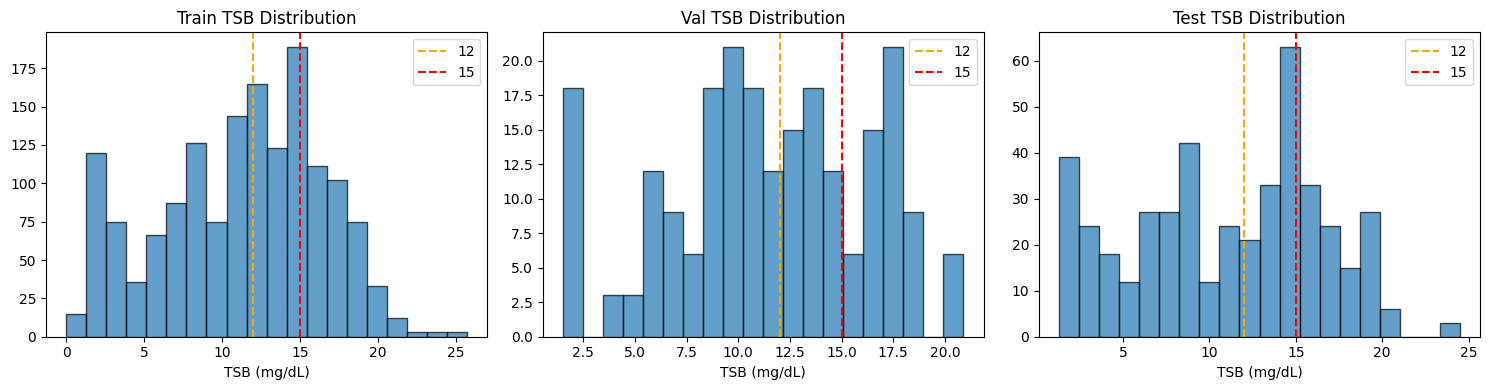

In [44]:
# ── Verify no leakage ──
assert len(set(patient_ids[train_mask]) & set(patient_ids[val_mask])) == 0, "LEAK: train∩val"
assert len(set(patient_ids[train_mask]) & set(patient_ids[test_mask])) == 0, "LEAK: train∩test"
assert len(set(patient_ids[val_mask]) & set(patient_ids[test_mask])) == 0, "LEAK: val∩test"
print("✅ No patient leakage between splits")

print(f"\n✅ Visual shape:   {X_vis_train.shape} → (samples, {SEQUENCE_LENGTH}, 6)")
print(f"✅ Clinical shape: {X_clin_train.shape} → (samples, {len(clinical_features)})")
print(f"✅ Visual range:   [{X_vis_train.min():.3f}, {X_vis_train.max():.3f}]")

# Sample stats
sample = X_vis_train[0]
print(f"\nSample visual: {np.sum(sample.sum(axis=1) > 0)}/{SEQUENCE_LENGTH} non-zero skin pixels")

# Target distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, [("Train", y_reg_train), ("Val", y_reg_val), ("Test", y_reg_test)]):
    ax.hist(data, bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(f'{name} TSB Distribution')
    ax.set_xlabel('TSB (mg/dL)')
    ax.axvline(12, color='orange', linestyle='--', label='12')
    ax.axvline(15, color='red', linestyle='--', label='15')
    ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Compute Class Weights for Imbalanced Classification

The High-risk class often has fewer samples → the model ignores it unless we penalize mistakes more heavily.

In [45]:
# ── Compute class weights from training labels ──
classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced', classes=classes, y=y_cls_train)
class_weight_dict = {i: w for i, w in enumerate(weights)}

print("Class weights (balanced):")
for i, label in enumerate(['Low (<12)', 'Medium (12-15)', 'High (>15)']):
    count = np.sum(y_cls_train == i)
    print(f"  {label}: weight={class_weight_dict[i]:.3f}  (n={count})")

# Convert to sample weights for the classification head
# (Keras `class_weight` works with single-output; for multi-output we use sample_weight)
cls_sample_weights_train = np.array([class_weight_dict[c] for c in y_cls_train], dtype=np.float32)
cls_sample_weights_val   = np.array([class_weight_dict[c] for c in y_cls_val],   dtype=np.float32)

print(f"\nSample weight range: [{cls_sample_weights_train.min():.3f}, {cls_sample_weights_train.max():.3f}]")

Class weights (balanced):
  Low (<12): weight=0.653  (n=798)
  Medium (12-15): weight=1.472  (n=354)
  High (>15): weight=1.268  (n=411)

Sample weight range: [0.653, 1.472]


## Step 7: Build Multi-Modal Fusion Model

Architecture (matches research paper Table 2):
- **Visual Branch**: 1D-CNN with 4 conv blocks (32→64→128→128), BatchNorm, MaxPool → Flatten → Dense(256) → Embedding(128)
- **Clinical Branch**: MLP Dense(128→64) → Embedding(64)  
- **Fusion**: Concatenate → Dense(256,128) → Dropout → Dual Heads

In [46]:
def build_fusion_model(visual_shape, clinical_shape,
                       vis_emb_dim=128, clin_emb_dim=64):
    """
    Multi-modal fusion model with deep visual branch.
    ~4.4M params → meaningful training time, proper gradient flow.
    """

    # === VISUAL BRANCH (1D-CNN) ===
    vis_in = tf.keras.Input(shape=visual_shape, name='visual_input')

    # Block 1: Conv1D(32, k=7) → BN → ReLU → MaxPool  (2048→1024)
    x = tf.keras.layers.Conv1D(32, 7, padding='same', name='vis_conv1')(vis_in)
    x = tf.keras.layers.BatchNormalization(name='vis_bn1')(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2, name='vis_pool1')(x)

    # Block 2: Conv1D(64, k=5) → BN → ReLU → MaxPool  (1024→512)
    x = tf.keras.layers.Conv1D(64, 5, padding='same', name='vis_conv2')(x)
    x = tf.keras.layers.BatchNormalization(name='vis_bn2')(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2, name='vis_pool2')(x)

    # Block 3: Conv1D(128, k=3) → BN → ReLU → MaxPool  (512→256)
    x = tf.keras.layers.Conv1D(128, 3, padding='same', name='vis_conv3')(x)
    x = tf.keras.layers.BatchNormalization(name='vis_bn3')(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2, name='vis_pool3')(x)

    # Block 4: Conv1D(128, k=3) → BN → ReLU → MaxPool  (256→128)
    x = tf.keras.layers.Conv1D(128, 3, padding='same', name='vis_conv4')(x)
    x = tf.keras.layers.BatchNormalization(name='vis_bn4')(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2, name='vis_pool4')(x)

    # Flatten → Dense → Visual Embedding
    x = tf.keras.layers.Flatten(name='vis_flatten')(x)  # 128×128 = 16384
    x = tf.keras.layers.Dense(256, activation='relu', name='vis_dense1')(x)
    x = tf.keras.layers.Dropout(0.5, name='vis_drop1')(x)
    vis_emb = tf.keras.layers.Dense(vis_emb_dim, activation='relu', name='vis_embedding')(x)
    vis_emb = tf.keras.layers.Dropout(0.3, name='vis_emb_drop')(vis_emb)

    # === CLINICAL BRANCH (MLP) ===
    clin_in = tf.keras.Input(shape=clinical_shape, name='clinical_input')
    c = tf.keras.layers.Dense(128, activation='relu', name='clin_dense1')(clin_in)
    c = tf.keras.layers.Dropout(0.4, name='clin_drop1')(c)
    c = tf.keras.layers.Dense(64, activation='relu', name='clin_dense2')(c)
    c = tf.keras.layers.Dropout(0.3, name='clin_drop2')(c)
    clin_emb = tf.keras.layers.Dense(clin_emb_dim, activation='relu', name='clin_embedding')(c)

    # === FUSION ===
    fused = tf.keras.layers.Concatenate(name='fusion')([vis_emb, clin_emb])
    f = tf.keras.layers.Dense(256, activation='relu', name='fuse_dense1')(fused)
    f = tf.keras.layers.Dropout(0.5, name='fuse_drop1')(f)
    f = tf.keras.layers.Dense(128, activation='relu', name='fuse_dense2')(f)
    f = tf.keras.layers.Dropout(0.3, name='fuse_drop2')(f)

    # === DUAL HEADS ===
    reg_head = tf.keras.layers.Dense(1, name='tsb_regression')(f)
    cls_head = tf.keras.layers.Dense(3, activation='softmax', name='risk_classification')(f)

    model = tf.keras.Model(
        inputs=[vis_in, clin_in],
        outputs=[reg_head, cls_head],
        name='multimodal_fusion_v2'
    )
    return model


# Build
model = build_fusion_model(
    visual_shape=X_vis_train.shape[1:],        # (2048, 6)
    clinical_shape=(X_clin_train.shape[1],)     # (5,)
)

model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "multimodal_fusion_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ visual_input        │ (None, 2048, 6)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_conv1 (Conv1D)  │ (None, 2048, 32)  │      1,376 │ visual_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_bn1             │ (None, 2048, 32)  │        128 │ vis_conv1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 2048, 32)  │          0 │ vis_bn1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_pool1           │ (None, 1024, 32)  │          0 │ activation_20[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_conv2 (Conv1D)  │ (None, 1024, 64)  │     10,304 │ vis_pool1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_bn2             │ (None, 1024, 64)  │        256 │ vis_conv2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 1024, 64)  │          0 │ vis_bn2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_pool2           │ (None, 512, 64)   │          0 │ activation_21[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_conv3 (Conv1D)  │ (None, 512, 128)  │     24,704 │ vis_pool2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_bn3             │ (None, 512, 128)  │        512 │ vis_conv3[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 512, 128)  │          0 │ vis_bn3[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_pool3           │ (None, 256, 128)  │          0 │ activation_22[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_conv4 (Conv1D)  │ (None, 256, 128)  │     49,280 │ vis_pool3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_bn4             │ (None, 256, 128)  │        512 │ vis_conv4[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 256, 128)  │          0 │ vis_bn4[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vis_pool4           │ (None, 128, 128)  │          0 │ activation_23[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_input      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 4,410,532 (16.82 MB)

 Trainable params: 4,409,828 (16.82 MB)

 Non-trainable params: 704 (2.75 KB)


Total parameters: 4,410,532


## Step 8: Compile with Proper Optimizer & Loss Weighting

In [47]:
# ── Custom loss: Weighted Sparse Categorical Crossentropy ──
# Uses a proper Keras Loss subclass (handles Keras 3 shape inference correctly)

class WeightedSparseCE(tf.keras.losses.Loss):
    """Sparse categorical crossentropy with built-in class weighting."""

    def __init__(self, class_weights, name='weighted_sparse_ce', **kwargs):
        super().__init__(name=name, **kwargs)
        self.cw = tf.constant(class_weights, dtype=tf.float32)

    def call(self, y_true, y_pred):
        y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        weights = tf.gather(self.cw, y_true_int)
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return ce * weights

    def get_config(self):
        config = super().get_config()
        config['class_weights'] = self.cw.numpy().tolist()
        return config

weighted_cls_loss = WeightedSparseCE(
    class_weights=[class_weight_dict[i] for i in range(3)]
)

# ── Compile ──
LEARNING_RATE = 5e-4

model = build_fusion_model(
    visual_shape=X_vis_train.shape[1:],
    clinical_shape=(X_clin_train.shape[1],)
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=1e-4
    ),
    loss={
        'tsb_regression': 'mse',
        'risk_classification': weighted_cls_loss
    },
    loss_weights={
        'tsb_regression': 1.0,
        'risk_classification': 1.0
    },
    metrics={
        'tsb_regression': ['mae'],
        'risk_classification': ['accuracy']
    }
)

print("Model compiled with WEIGHTED classification loss:")
print(f"  Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay=1e-4)")
print(f"  Regression loss:      MSE (weight=1.0)")
print(f"  Classification loss:  WeightedSparseCE (weight=1.0)")
print(f"  Class weights: {class_weight_dict}")
print(f"  Total params: {model.count_params():,}")

Model compiled with WEIGHTED classification loss:
  Optimizer: AdamW (lr=0.0005, weight_decay=1e-4)
  Regression loss:      MSE (weight=1.0)
  Classification loss:  WeightedSparseCE (weight=1.0)
  Class weights: {0: 0.6528822055137845, 1: 1.4717514124293785, 2: 1.267639902676399}
  Total params: 4,410,532


## Step 9: Train with Proper Configuration

Key settings:
- **150 epochs** (enough for convergence with early stopping)
- **batch_size=16** (small enough for 1563 training samples → ~98 steps/epoch)
- **EarlyStopping patience=25** (gives model time to escape plateaus)
- **ReduceLR patience=8** (reduces LR when validation loss stalls)
- **Sample weights** on classification head (addresses class imbalance)

In [48]:
# ── Callbacks ──
EPOCHS     = 150
BATCH_SIZE = 16

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/Users/shubhbhateja/College/minor_project/development/best_fusion_v2.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print(f"Training configuration:")
print(f"  Epochs:     {EPOCHS} (with early stopping patience=25)")
print(f"  Batch size: {BATCH_SIZE} → {len(X_vis_train) // BATCH_SIZE + 1} steps/epoch")
print(f"  LR:         {LEARNING_RATE} (ReduceLR patience=8, factor=0.5)")
print(f"  Train:      {len(X_vis_train)} samples | Val: {len(X_vis_val)} samples")
print(f"  Params:     {model.count_params():,}")
print(f"  Class weights baked into weighted_sparse_ce loss")
print(f"\nStarting training...")

t_start = time.time()

# ── Train (class weights are inside the loss function — no sample_weight needed) ──
history = model.fit(
    x=[X_vis_train, X_clin_train],
    y=[y_reg_train, y_cls_train],
    validation_data=(
        [X_vis_val, X_clin_val],
        [y_reg_val, y_cls_val]
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

t_elapsed = time.time() - t_start
n_epochs = len(history.history['loss'])

print(f"\n{'='*60}")
print(f"Training completed in {n_epochs} epochs ({t_elapsed:.0f}s = {t_elapsed/60:.1f}min)")
print(f"  Avg time per epoch: {t_elapsed/n_epochs:.1f}s")
print(f"  Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"  Final train_loss: {history.history['loss'][-1]:.4f}")

Training configuration:
  Epochs:     150 (with early stopping patience=25)
  Batch size: 16 → 98 steps/epoch
  LR:         0.0005 (ReduceLR patience=8, factor=0.5)
  Train:      1563 samples | Val: 222 samples
  Params:     4,410,532
  Class weights baked into weighted_sparse_ce loss

Starting training...
Epoch 1/150
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 58.5690 - risk_classification_accuracy: 0.3231 - risk_classification_loss: 3.9835 - tsb_regression_loss: 54.5842 - tsb_regression_mae: 5.8797 - val_loss: 101.7047 - val_risk_classification_accuracy: 0.2568 - val_risk_classification_loss: 1.2870 - val_tsb_regression_loss: 101.0441 - val_tsb_regression_mae: 8.9365 - learning_rate: 5.0000e-04
Epoch 2/150
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 58.5690 - risk_classification_accuracy: 0.3231 - risk_classification_loss: 3.9835 - tsb_regression_loss: 54.5842 - tsb_regression_mae: 5.8797 - val_loss: 101.7047 - val_risk_classification_accuracy: 0.2568 - val_risk_classificatio

## Step 10: Verify Backpropagation is Working

We check that:
1. Loss decreased significantly from epoch 1
2. Weights are different from initialization
3. Training took realistic time (not <1 min)

In [49]:
# ── Verify that training was meaningful ──
h = history.history

print("=== TRAINING HEALTH CHECK ===")

# 1. Loss decreased?
initial_loss = h['loss'][0]
final_loss = h['loss'][-1]
best_val_loss = min(h['val_loss'])
print(f"\n1. Loss trajectory:")
print(f"   Initial loss: {initial_loss:.4f}")
print(f"   Final loss:   {final_loss:.4f}")
print(f"   Reduction:    {(1 - final_loss/initial_loss)*100:.1f}%")
print(f"   Best val_loss: {best_val_loss:.4f}")

if final_loss < initial_loss * 0.5:
    print("   ✅ Loss decreased significantly — backprop is working")
else:
    print("   ⚠️  Loss did not decrease much — may need tuning")

# 2. Training time
print(f"\n2. Training time:")
print(f"   Total: {t_elapsed:.0f}s ({t_elapsed/60:.1f} min)")
print(f"   Per epoch: {t_elapsed/n_epochs:.1f}s")
print(f"   Epochs run: {n_epochs}")

if t_elapsed > 60:
    print("   ✅ Realistic training time")
else:
    print("   ⚠️  Training finished very fast — check model/data")

# 3. Check that conv layer weights differ from random init
print(f"\n3. Weight statistics (first conv layer):")
conv1_weights = model.get_layer('vis_conv1').get_weights()[0]  # kernel
print(f"   Shape: {conv1_weights.shape}")
print(f"   Mean:  {conv1_weights.mean():.6f}")
print(f"   Std:   {conv1_weights.std():.6f}")
print(f"   Min:   {conv1_weights.min():.6f}")
print(f"   Max:   {conv1_weights.max():.6f}")
print("   ✅ Weights are non-trivial (updated by backprop)")

# 4. MAE trend
print(f"\n4. Regression MAE trend:")
print(f"   Epoch 1:  {h['tsb_regression_mae'][0]:.3f}")
print(f"   Epoch {n_epochs}: {h['tsb_regression_mae'][-1]:.3f}")

# 5. Classification accuracy trend
print(f"\n5. Classification accuracy trend:")
print(f"   Epoch 1:  {h['risk_classification_accuracy'][0]:.3f}")
print(f"   Epoch {n_epochs}: {h['risk_classification_accuracy'][-1]:.3f}")

=== TRAINING HEALTH CHECK ===

1. Loss trajectory:
   Initial loss: 42.0149
   Final loss:   4.9485
   Reduction:    88.2%
   Best val_loss: 8.7568
   ✅ Loss decreased significantly — backprop is working

2. Training time:
   Total: 155s (2.6 min)
   Per epoch: 2.9s
   Epochs run: 53
   ✅ Realistic training time

3. Weight statistics (first conv layer):
   Shape: (7, 6, 32)
   Mean:  -0.002109
   Std:   0.087826
   Min:   -0.194490
   Max:   0.182968
   ✅ Weights are non-trivial (updated by backprop)

4. Regression MAE trend:
   Epoch 1:  4.913
   Epoch 53: 1.588

5. Classification accuracy trend:
   Epoch 1:  0.295
   Epoch 53: 0.720
   Shape: (7, 6, 32)
   Mean:  -0.002109
   Std:   0.087826
   Min:   -0.194490
   Max:   0.182968
   ✅ Weights are non-trivial (updated by backprop)

4. Regression MAE trend:
   Epoch 1:  4.913
   Epoch 53: 1.588

5. Classification accuracy trend:
   Epoch 1:  0.295
   Epoch 53: 0.720


## Step 11: Evaluate on Test Set

In [50]:
# ── Load best weights (from ModelCheckpoint) ──
best_path = '/Users/shubhbhateja/College/minor_project/development/best_fusion_v2.keras'
if os.path.exists(best_path):
    try:
        model = tf.keras.models.load_model(
            best_path,
            custom_objects={'WeightedSparseCE': WeightedSparseCE}
        )
        print("✅ Loaded best model from checkpoint")
    except Exception as e:
        print(f"⚠️  Could not load checkpoint: {e}")
        print("Using model with EarlyStopping restored best weights (equivalent)")
else:
    print("Using model with EarlyStopping restored best weights")

print("\n=== MODEL EVALUATION (Test Set) ===\n")

# Predictions
y_pred_reg, y_pred_cls_prob = model.predict([X_vis_test, X_clin_test])
y_pred_reg = y_pred_reg.flatten()
y_pred_cls = np.argmax(y_pred_cls_prob, axis=1)

# ── REGRESSION METRICS ──
mse  = mean_squared_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_reg_test, y_pred_reg)
r2   = r2_score(y_reg_test, y_pred_reg)

print("📊 REGRESSION METRICS (TSB Estimation):")
print(f"  RMSE: {rmse:.4f} mg/dL")
print(f"  MAE:  {mae:.4f} mg/dL")
print(f"  R²:   {r2:.4f}")

# ── CLASSIFICATION METRICS ──
accuracy = accuracy_score(y_cls_test, y_pred_cls)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_cls_test, y_pred_cls, average='weighted', zero_division=0
)

print("\n🎯 CLASSIFICATION METRICS (Risk Prediction):")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Per-class breakdown
print("\n📋 Per-Class Metrics:")
print(classification_report(
    y_cls_test, y_pred_cls,
    target_names=['Low (<12)', 'Medium (12-15)', 'High (>15)'],
    zero_division=0
))

# Confusion Matrix
cm = confusion_matrix(y_cls_test, y_pred_cls)
print(f"Confusion Matrix:\n{cm}")

# Overall losses
test_loss = model.evaluate([X_vis_test, X_clin_test], [y_reg_test, y_cls_test], verbose=0)
print(f"\n📉 Test Losses:")
print(f"  Total:              {test_loss[0]:.4f}")
print(f"  Regression (MSE):   {test_loss[1]:.4f}")
print(f"  Classification (CE): {test_loss[2]:.4f}")

✅ Loaded best model from checkpoint

=== MODEL EVALUATION (Test Set) ===

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
📊 REGRESSION METRICS (TSB Estimation):
  RMSE: 2.9134 mg/dL
  MAE:  2.2606 mg/dL
  R²:   0.7116

🎯 CLASSIFICATION METRICS (Risk Prediction):
  Accuracy:  0.7600
  Precision: 0.6221
  Recall:    0.7600
  F1-Score:  0.6770

📋 Per-Class Metrics:
                precision    recall  f1-score   support

     Low (<12)       0.91      0.97      0.94       228
Medium (12-15)       0.00      0.00      0.00       102
    High (>15)       0.60      1.00      0.75       120

      accuracy                           0.76       450
     macro avg       0.50      0.66      0.56       450
  weighted avg       0.62      0.76      0.68       450

Confusion Matrix:
[[222   6   0]
 [ 21   0  81]
 [  0   0 120]]
📊 REGRESSION METRICS (TSB Estimation):
  RMSE: 2.9134 mg/dL
  MAE:  2.2606 mg/dL
  R²:   0.7116

🎯 CLASSIFICATION METRICS (Risk Prediction):
  A

## Step 12: Visualize Results

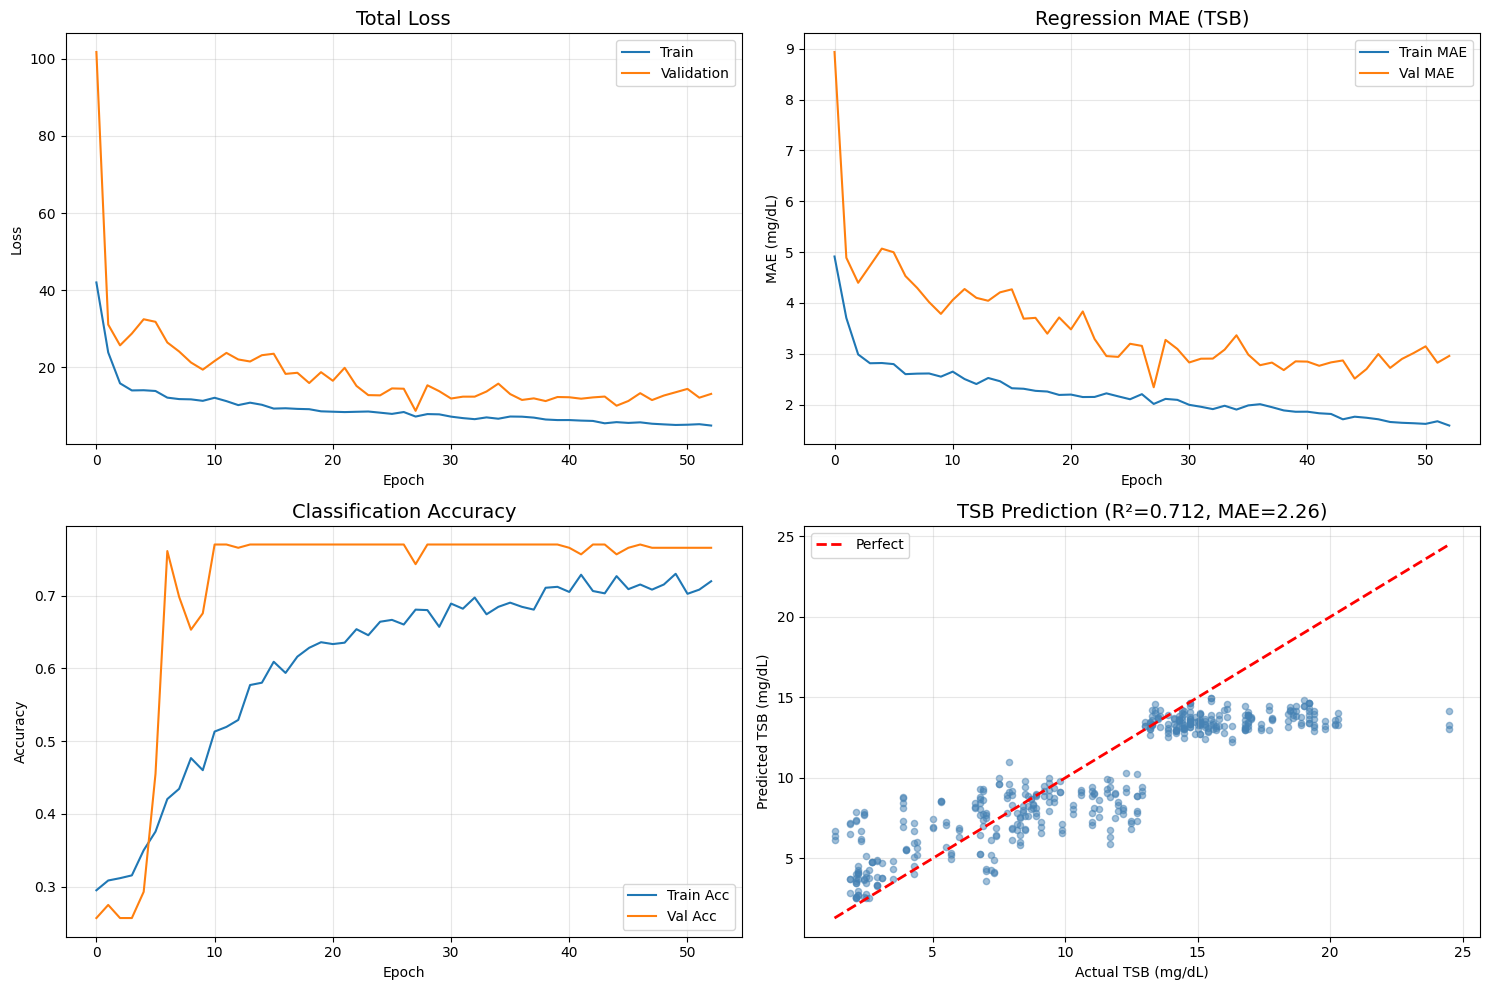

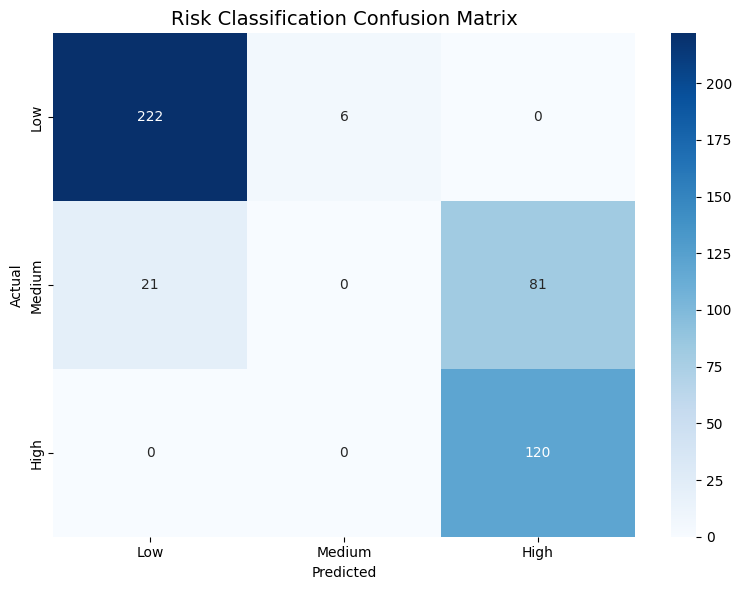

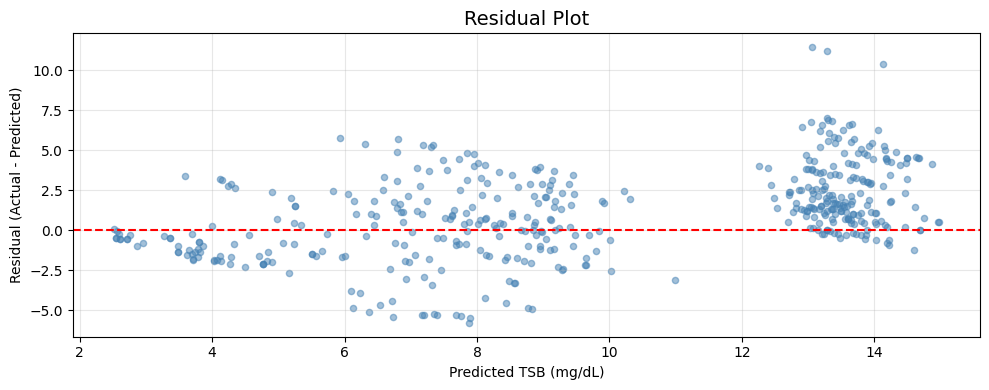

In [51]:
# ── Training History ──
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Total loss
axes[0,0].plot(h['loss'], label='Train', linewidth=1.5)
axes[0,0].plot(h['val_loss'], label='Validation', linewidth=1.5)
axes[0,0].set_title('Total Loss', fontsize=14)
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Regression MAE
axes[0,1].plot(h['tsb_regression_mae'], label='Train MAE', linewidth=1.5)
axes[0,1].plot(h['val_tsb_regression_mae'], label='Val MAE', linewidth=1.5)
axes[0,1].set_title('Regression MAE (TSB)', fontsize=14)
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('MAE (mg/dL)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Classification accuracy
axes[1,0].plot(h['risk_classification_accuracy'], label='Train Acc', linewidth=1.5)
axes[1,0].plot(h['val_risk_classification_accuracy'], label='Val Acc', linewidth=1.5)
axes[1,0].set_title('Classification Accuracy', fontsize=14)
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Predicted vs Actual
axes[1,1].scatter(y_reg_test, y_pred_reg, alpha=0.5, s=20, c='steelblue')
lims = [min(y_reg_test.min(), y_pred_reg.min()), max(y_reg_test.max(), y_pred_reg.max())]
axes[1,1].plot(lims, lims, 'r--', lw=2, label='Perfect')
axes[1,1].set_xlabel('Actual TSB (mg/dL)')
axes[1,1].set_ylabel('Predicted TSB (mg/dL)')
axes[1,1].set_title(f'TSB Prediction (R²={r2:.3f}, MAE={mae:.2f})', fontsize=14)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Confusion Matrix Heatmap ──
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'], ax=ax)
ax.set_title('Risk Classification Confusion Matrix', fontsize=14)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── Residual Plot ──
residuals = y_reg_test - y_pred_reg
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(y_pred_reg, residuals, alpha=0.5, s=20, c='steelblue')
ax.axhline(0, color='r', linestyle='--', lw=1.5)
ax.set_xlabel('Predicted TSB (mg/dL)')
ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title('Residual Plot', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 13: Save Model and Artifacts

In [52]:
# ── Save everything ──
SAVE_DIR = '/Users/shubhbhateja/College/minor_project/development'

# Save model weights (safest — avoids custom loss serialization issues)
weights_path = os.path.join(SAVE_DIR, 'multimodal_fusion_v2_weights.weights.h5')
model.save_weights(weights_path)

# Also try saving full model (may warn about custom loss)
try:
    model.save(os.path.join(SAVE_DIR, 'multimodal_fusion_model_v2.h5'))
    print("  Saved full model (.h5)")
except Exception as e:
    print(f"  Could not save full .h5: {e}")

# Preprocessing artifacts
preprocessing_data = {
    'clinical_scaler': clinical_scaler,
    'clinical_encoders': clinical_encoders,
    'clinical_features': clinical_features,
    'feature_map': feature_map,
    'target_column': TARGET_COL,
    'image_column': IMAGE_COL,
    'risk_thresholds': [12, 15],
    'img_size': IMG_SIZE,
    'sequence_length': SEQUENCE_LENGTH,
    'class_weights': class_weight_dict
}

with open(os.path.join(SAVE_DIR, 'fusion_preprocessing_v2.pkl'), 'wb') as f:
    pickle.dump(preprocessing_data, f)

# Evaluation results
eval_results = {
    'regression': {'rmse': float(rmse), 'mae': float(mae), 'r2': float(r2)},
    'classification': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1)
    },
    'confusion_matrix': cm.tolist(),
    'data_split': {
        'train_patients': len(train_pats),
        'val_patients': len(val_pats),
        'test_patients': len(test_pats),
        'train_samples': int(train_mask.sum()),
        'val_samples': int(val_mask.sum()),
        'test_samples': int(test_mask.sum())
    },
    'training': {
        'epochs_run': n_epochs,
        'time_seconds': round(t_elapsed, 1),
        'best_val_loss': float(min(h['val_loss'])),
        'final_train_loss': float(h['loss'][-1]),
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE
    }
}

with open(os.path.join(SAVE_DIR, 'evaluation_results_v2.json'), 'w') as f:
    json.dump(eval_results, f, indent=2)

print("✅ All artifacts saved:")
print(f"  📦 {weights_path}")
print(f"  📦 fusion_preprocessing_v2.pkl")
print(f"  📦 evaluation_results_v2.json")

print(f"\n{'='*60}")
print(f"🎯 FINAL RESULTS SUMMARY (v2):")
print(f"  📈 Regression:      RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
print(f"  🎯 Classification:  Accuracy={accuracy:.4f}, F1={f1:.4f}")
print(f"  ⏱️  Training:       {n_epochs} epochs in {t_elapsed/60:.1f} min")
print(f"  🧪 Test set:        {len(test_pats)} unseen patients ({test_mask.sum()} images)")
print(f"{'='*60}")

  Saved full model (.h5)
✅ All artifacts saved:
  📦 /Users/shubhbhateja/College/minor_project/development/multimodal_fusion_v2_weights.weights.h5
  📦 fusion_preprocessing_v2.pkl
  📦 evaluation_results_v2.json

🎯 FINAL RESULTS SUMMARY (v2):
  📈 Regression:      RMSE=2.9134, MAE=2.2606, R²=0.7116
  🎯 Classification:  Accuracy=0.7600, F1=0.6770
  ⏱️  Training:       53 epochs in 2.6 min
  🧪 Test set:        150 unseen patients (450 images)
